# Tópicos Especiais em Sistema Computacionais II - 2026.1
## **Projeto 03 - k-NN**
Autores: José Cláudio Alves Sobrinho e Ingridy Duarte Costa



## INTRODUÇÃO E CONTEXTO

A indústria vinícola depende historicamente de avaliações humanas — caras, lentas e subjetivas. Um modelo preditivo de qualidade tem aplicações diretas no controle de lotes antes do engarrafamento, na precificação e na certificação de denominação de origem por órgãos reguladores. Na pesquisa enológica (ciência que estuda a produção, conservação e análise de vinhos), ele também ajuda a identificar quais variáveis químicas mais influenciam a percepção de qualidade, orientando decisões de produção.

Plataformas como a Vivino (https://www.vivino.com/BR/pt-BR/) já utilizam machine learning com esse objetivo. No Brasil, o contexto do Vale do São Francisco — maior polo de vinhos tropicais do mundo, localizado aqui no Nordeste — torna o problema especialmente próximo e motivador para nossa realidade.

Neste projeto, você é convidado a construir um modelo de classificação de vinhos em três categorias de qualidade (baixa, média e alta) a partir de um conjunto de dados químicos utilizando o k-NN (k-Nearest Neighbors).

## Preparação do Ambiente

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import requests
import io
import zipfile


## 1. Preparação dos dados: carregue o dataset e recodifique a variável quality em três classes: notas $\leq 5$ como ruim, $6-7$ como médio e $\geq 8$ como bom. Em seguida, normalize todos os atributos utilizando Min-Max ou Z-score. Justifique por que a normalização é uma etapa obrigatória para o k-NN.

In [ ]:
url = "https://archive.ics.uci.edu/static/public/186/wine+quality.zip"
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('winequality-red.csv') as f:
        df = pd.read_csv(f, sep=';')

def categorize_quality(score):
    if score <= 5:
        return 'ruim'
    elif score >= 6 and score <= 7:
        return 'médio'
    else:
        return 'bom'

df['quality_label'] = df['quality'].apply(categorize_quality)


X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Dados carregados e normalizados com sucesso!")
print(df['quality_label'].value_counts())

Dados carregados e normalizados com sucesso!
quality_label
médio    837
ruim     744
bom       18
Name: count, dtype: int64


O algoritmo k-NN calcula a "proximidade" entre amostras usando métricas de distância (como a Euclidiana). Se os dados não forem normalizados, variáveis com escalas numericamente maiores (ex: "Total Sulfur Dioxide" que chega a 289) terão um peso muito maior no cálculo do que variáveis com escalas pequenas (ex: "Chlorides" que gira em torno de 0.08). A normalização coloca todos os atributos na mesma escala (entre 0 e 1, por exemplo), garantindo que todos contribuam igualmente para a classificação.

## 2. Divisão treino/teste: divida os dados em $80\%$ para treino e $20\%$ para teste, utilizando divisão estratificada para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=42
)

## 3. Treinamento e escolha do $k$: treine o modelo para diferentes valores de $k$ (ex: $1, 3, 5, 7, 11$) utilizando validação cruzada de $5$ folds sobre o conjunto de treino. Plote a acurácia média em função de $k$ e escolha o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos de $k$?

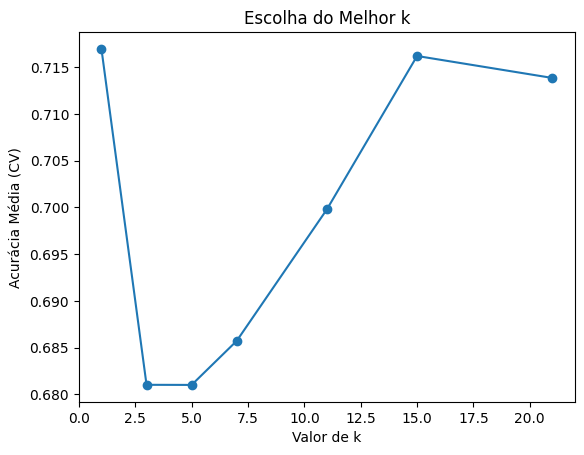

In [ ]:
k_values = [1, 3, 5, 7, 11, 15, 21]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5) # 5 folds
    cv_scores.append(scores.mean())

# Plotagem
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia Média (CV)')
plt.title('Escolha do Melhor k')
plt.show()

Valores muito baixos de k (ex: 1) tendem ao "overfitting" (captam ruído).

Valores muito altos de k tendem ao "underfitting" (o modelo fica muito simples e ignora padrões locais).

## 4. Avaliação do modelo: utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe. Responda: Entre quais classes o modelo erra com mais frequência?

In [ ]:
best_k = k_values[cv_scores.index(max(cv_scores))]
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  0   4   0]
 [  1 134  32]
 [  0  35 114]]
              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       médio       0.77      0.80      0.79       167
        ruim       0.78      0.77      0.77       149

    accuracy                           0.78       320
   macro avg       0.52      0.52      0.52       320
weighted avg       0.77      0.78      0.77       320



O modelo erra com mais frequência entre as classes 'médio' e 'ruim'.

De acordo com a matriz de confusão, houve 35 casos em que vinhos da classe 'ruim' foram erroneamente classificados como 'médio' e 32 casos em que vinhos 'médio' foram classificados como 'ruim'. Além disso, o modelo falhou completamente em identificar a classe 'bom', classificando 100% das suas amostras (4 no total) como 'médio', o que indica uma dificuldade do algoritmo em distinguir as nuances químicas das classes extremas devido ao desbalanceamento dos dados (poucas amostras da classe 'bom').